# Field Overlap Calculator

This notebook computes the numerical overlap between two transverse optical fields according to the discrete approximation:

$$\langle\psi_1|\psi_2\rangle \approx \sum_0^N \sum_0^N h^2\psi^{*}_1(i, j) \psi_2(i, j)$$

where $h$ is the step size (pixel size) and the sum runs over the discretized grid.

In [11]:
import numpy as np
from scipy.fft import fft2, fftfreq, ifft2, fftshift, ifftshift
import scipy as sp
import matplotlib.pyplot as plt
import sys
import math
import os

import yaml 
from yaml import Loader

from optical_functions import LG, cart2pol, oamModes, TotInt, setKnotType, norm_field
from knot_funcs import propTF

# Establishing Constants 
cm = 1e-2
mm = 1e-3
um = 1e-6 
nm = 1e-9

## Define Coordinate Space

We set up the same coordinate system as used in the OpticalModeSorter notebook.

In [15]:
# Define the coordinate space 
la = 0.78*um
k = (2*np.pi)/la  # [m^-1] wavenumber    
N = 128 # [Number of points per dimension]
maxx = 20*um*N # Full length of the numerical window (m)

# Space definition 
dx = maxx/N
dy = maxx/N 

# Step size h (pixel size)
h = dx

X = dx*(np.arange(N) - N //2)
Y = dy*(np.arange(N) - N //2)

xx, yy = np.meshgrid(X, Y)
r, phi = cart2pol(xx, yy)

print(f"Grid size: {N}x{N}")
print(f"Step size (h): {h*1e6:.4f} µm")
print(f"Window size: {maxx*1e6:.2f} µm")

Grid size: 128x128
Step size (h): 20.0000 µm
Window size: 2560.00 µm


## Define the Field Overlap Function
^{*}_1(\rho, \phi)\psi_2(\rho, \phi)\rho d\rho d\phi$$

In the discrete approximation on a Cartesian grid:

$$\langle\psi_1|\psi_2\rangle \approx \sum_{i=0}^{N} \sum_{j=0}^{N} h^2 \psi_1(i, j) \psi_2(i, j)$$

In [16]:
def field_overlap(psi1, psi2, h):
    """
    Compute the numerical overlap between two transverse fields.
    
    Parameters:
    -----------
    psi1 : ndarray (complex)
        First field (N x N array)
    psi2 : ndarray (complex)
        Second field (N x N array)
    h : float
        Step size (pixel size) in meters
    
    Returns:
    --------
    overlap : complex
        The overlap integral <psi1|psi2>
    """
    # Compute the discrete overlap integral
    overlap = np.sum(np.conjugate(psi1) * psi2) * h**2
    return overlap

def field_overlap_magnitude(psi1, psi2, h):
    """
    Compute the magnitude of the overlap between two fields.
    
    Returns:
    --------
    magnitude : float
        The absolute value of the overlap |<psi1|psi2>|
    """
    overlap = field_overlap(psi1, psi2, h)
    return np.abs(overlap)

def field_overlap_squared(psi1, psi2, h):
    """
    Compute the squared magnitude of the overlap (overlap probability).
    
    Returns:
    --------
    overlap_sq : float
        The squared overlap |<psi1|psi2>|^2
    """
    overlap = field_overlap(psi1, psi2, h)
    return np.abs(overlap)**2

## Example 1: Overlap Between Two LG Modes

Let's test the overlap function with Laguerre-Gaussian modes, which are orthogonal.

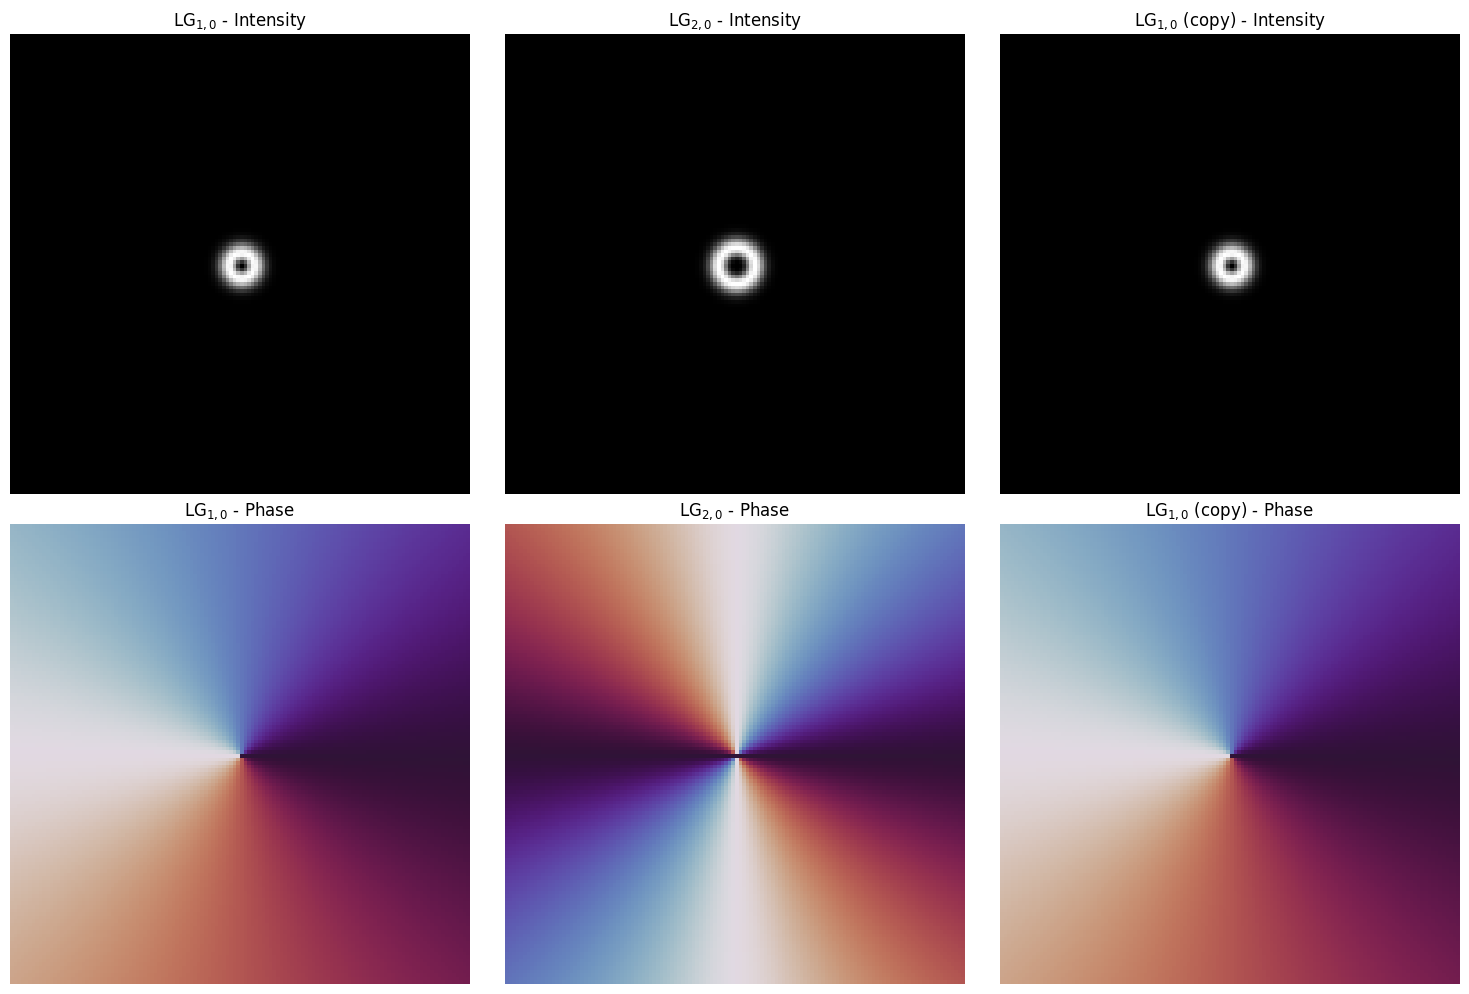

In [17]:
# Define beam waist
w0 = 0.10 * mm
z = 0  # at beam waist

# Create two different LG modes
# LG(RHO, PHI, ell, p, w0, h, z, k)
LG_mode_1 = LG(r, phi, ell=1, p=0, w0=w0, h=h, z=z, k=k)  # LG_{1,0}
LG_mode_2 = LG(r, phi, ell=2, p=0, w0=w0, h=h, z=z, k=k)  # LG_{2,0}
LG_mode_same = LG(r, phi, ell=1, p=0, w0=w0, h=h, z=z, k=k)  # Another LG_{1,0}

# Visualize the fields
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# LG_mode_1
axes[0,0].imshow(np.abs(LG_mode_1)**2, cmap='gist_gray')
axes[0,0].set_title('LG$_{1,0}$ - Intensity')
axes[0,0].axis('off')
axes[1,0].imshow(np.angle(LG_mode_1), cmap='twilight')
axes[1,0].set_title('LG$_{1,0}$ - Phase')
axes[1,0].axis('off')

# LG_mode_2
axes[0,1].imshow(np.abs(LG_mode_2)**2, cmap='gist_gray')
axes[0,1].set_title('LG$_{2,0}$ - Intensity')
axes[0,1].axis('off')
axes[1,1].imshow(np.angle(LG_mode_2), cmap='twilight')
axes[1,1].set_title('LG$_{2,0}$ - Phase')
axes[1,1].axis('off')

# LG_mode_same
axes[0,2].imshow(np.abs(LG_mode_same)**2, cmap='gist_gray')
axes[0,2].set_title('LG$_{1,0}$ (copy) - Intensity')
axes[0,2].axis('off')
axes[1,2].imshow(np.angle(LG_mode_same), cmap='twilight')
axes[1,2].set_title('LG$_{1,0}$ (copy) - Phase')
axes[1,2].axis('off')

plt.tight_layout()
plt.show()

In [14]:
# Compute overlaps
overlap_12 = field_overlap(LG_mode_1, LG_mode_2, h)
overlap_11 = field_overlap(LG_mode_1, LG_mode_same, h)
overlap_22 = field_overlap(LG_mode_2, LG_mode_2, h)

print("\n=== Overlap Results for LG Modes ===")
print(f"\n<LG₁₀|LG₂₀> = {overlap_12:.6e}")
print(f"  Magnitude: |<LG₁₀|LG₂₀>| = {np.abs(overlap_12):.6e}")
print(f"  (Should be ~0 due to orthogonality)\n")

print(f"<LG₁₀|LG₁₀> = {overlap_11:.6e}")
print(f"  Magnitude: |<LG₁₀|LG₁₀>| = {np.abs(overlap_11):.6e}")
print(f"  (Should be ~1 due to normalization)\n")

print(f"<LG₂₀|LG₂₀> = {overlap_22:.6e}")
print(f"  Magnitude: |<LG₂₀|LG₂₀>| = {np.abs(overlap_22):.6e}")
print(f"  (Should be ~1 due to normalization)")


=== Overlap Results for LG Modes ===

<LG₁₀|LG₂₀> = 6.894698e-19+4.768372e-17j
  Magnitude: |<LG₁₀|LG₂₀>| = 4.768870e-17
  (Should be ~0 due to orthogonality)

<LG₁₀|LG₁₀> = 1.000000e+00-2.067952e-35j
  Magnitude: |<LG₁₀|LG₁₀>| = 1.000000e+00
  (Should be ~1 due to normalization)

<LG₂₀|LG₂₀> = 1.000000e+00+2.067952e-35j
  Magnitude: |<LG₂₀|LG₂₀>| = 1.000000e+00
  (Should be ~1 due to normalization)


## Example 2: Overlap Between Knotted Fields

Now let's compute overlaps between different knotted field configurations.

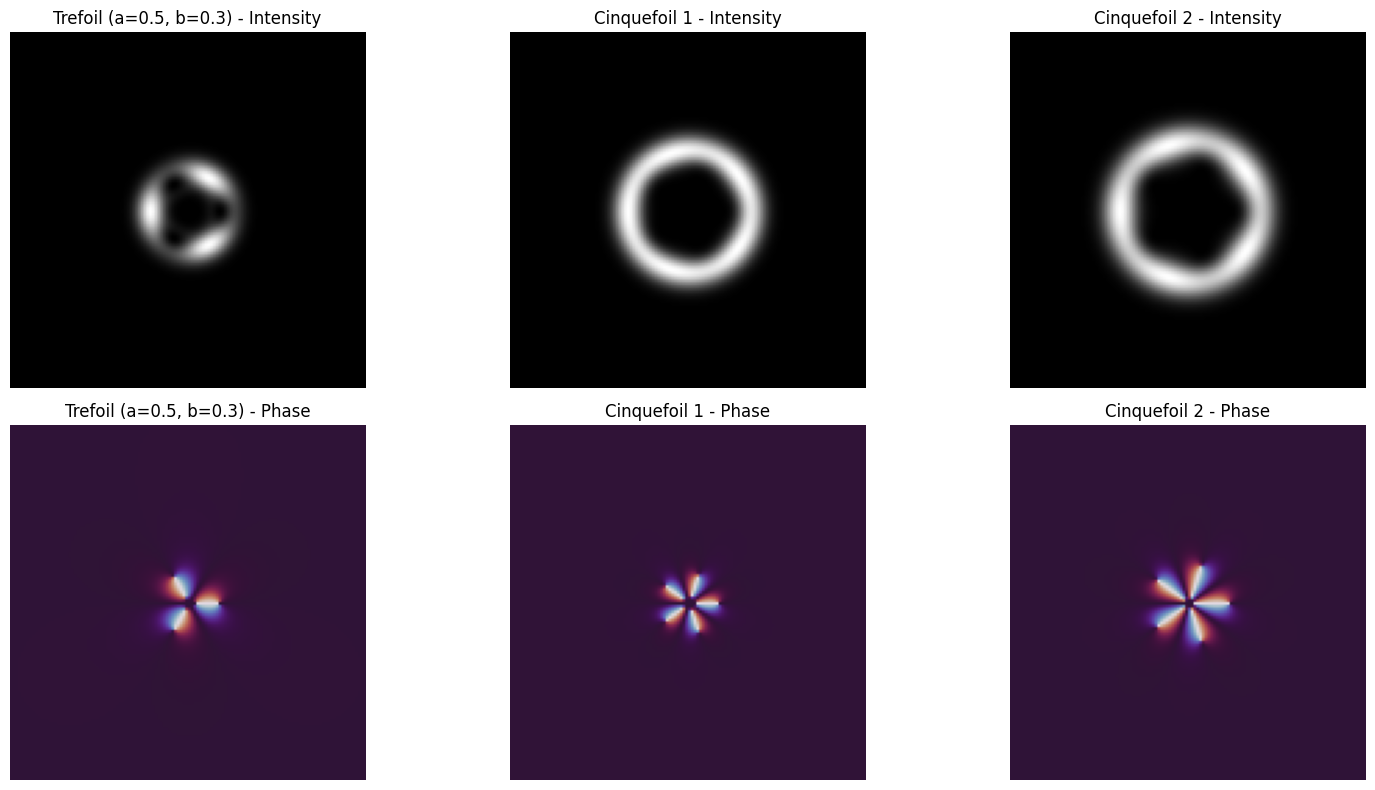

In [ ]:
# Define parameters for knotted fields
w0_knot = 0.10 * mm

# Create different knotted fields
# setKnotType(rr, phi, w0, knotType, shapeParams)
# shapeParams = [a, b, kk]

trefoil_1 = setKnotType(r, phi, w0_knot, 'Trefoil', [1.0, 1.0, 1.2])
cinquefoil_1 = setKnotType(r, phi, w0_knot, 'Cinquefoil', [1.2, 1.2, 1.4])
cinquefoil_2 = setKnotType(r, phi, w0_knot, 'Cinquefoil', [2.5, 2.5, 1.6])

# Make sure that each field is normalized 

trefoil_1 = norm_field(trefoil_1, h)
cinquefoil_1 = norm_field(cinquefoil_1, h)
cinquefoil_2 = norm_field(cinquefoil_2, h)

# Visualize the knotted fields
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

fields = [trefoil_1, cinquefoil_1, cinquefoil_2]
titles = ['Trefoil (a=0.5, b=0.3)', 'Cinquefoil 1', 'Cinquefoil 2']

for i, (field, title) in enumerate(zip(fields, titles)):
    axes[0, i].imshow(np.abs(field)**2, cmap='gist_gray')
    axes[0, i].set_title(f'{title} - Intensity')
    axes[0, i].axis('off')
    
    axes[1, i].imshow(np.angle(field), cmap='twilight')
    axes[1, i].set_title(f'{title} - Phase')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [24]:
# Compute overlaps between knotted fields
overlap_tref_cinq1 = field_overlap(trefoil_1, cinquefoil_1, h)
overlap_tref_cinq2 = field_overlap(trefoil_1, cinquefoil_2, h)
overlap_cinq1_cinq2 = field_overlap(cinquefoil_1, cinquefoil_2, h)

# Self overlaps (for normalization reference)
overlap_tref1_self = field_overlap(trefoil_1, trefoil_1, h)
overlap_cinq1_self = field_overlap(cinquefoil_1, cinquefoil_1, h)
overlap_cinq2_self = field_overlap(cinquefoil_2, cinquefoil_2, h)

print("\n=== Overlap Results for Knotted Fields ===")
print("\n--- Self Overlaps (Normalization Check) ---")
print(f"<Trefoil₁|Trefoil₁> = {np.abs(overlap_tref1_self):.6f}")
print(f"<Cinquefoil₁|Cinquefoil₁> = {np.abs(overlap_cinq1_self):.6f}")
print(f"<Cinquefoil₂|Cinquefoil₂> = {np.abs(overlap_cinq2_self):.6f}")

print("\n--- Cross Overlaps ---")
print(f"\n<Trefoil₁|Cinquefoil₁> = {overlap_tref_cinq1:.6e}")
print(f"  Magnitude: |<Trefoil₁|Cinquefoil₁>| = {np.abs(overlap_tref_cinq1):.6f}")
print(f"  Squared: |<Trefoil₁|Cinquefoil₁>|² = {np.abs(overlap_tref_cinq1)**2:.6f}")

print(f"\n<Trefoil₁|Cinquefoil₂> = {overlap_tref_cinq2:.6e}")
print(f"  Magnitude: |<Trefoil₁|Cinquefoil₂>| = {np.abs(overlap_tref_cinq2):.6f}")
print(f"  Squared: |<Trefoil₁|Cinquefoil₂>|² = {np.abs(overlap_tref_cinq2)**2:.6f}")

print(f"\n<Cinquefoil₁|Cinquefoil₂> = {overlap_cinq1_cinq2:.6e}")
print(f"  Magnitude: |<Cinquefoil₁|Cinquefoil₂>| = {np.abs(overlap_cinq1_cinq2):.6f}")
print(f"  Squared: |<Cinquefoil₁|Cinquefoil₂>|² = {np.abs(overlap_cinq1_cinq2)**2:.6f}")



=== Overlap Results for Knotted Fields ===

--- Self Overlaps (Normalization Check) ---
<Trefoil₁|Trefoil₁> = 1.000000
<Cinquefoil₁|Cinquefoil₁> = 1.000000
<Cinquefoil₂|Cinquefoil₂> = 1.000000

--- Cross Overlaps ---

<Trefoil₁|Cinquefoil₁> = 5.002492e-01-1.490116e-18j
  Magnitude: |<Trefoil₁|Cinquefoil₁>| = 0.500249
  Squared: |<Trefoil₁|Cinquefoil₁>|² = 0.250249

<Trefoil₁|Cinquefoil₂> = 2.978414e-01+1.490116e-18j
  Magnitude: |<Trefoil₁|Cinquefoil₂>| = 0.297841
  Squared: |<Trefoil₁|Cinquefoil₂>|² = 0.088710

<Cinquefoil₁|Cinquefoil₂> = 9.056859e-01-7.450581e-19j
  Magnitude: |<Cinquefoil₁|Cinquefoil₂>| = 0.905686
  Squared: |<Cinquefoil₁|Cinquefoil₂>|² = 0.820267


## Example 3: Overlap Matrix Visualization

Create a matrix showing all pairwise overlaps between a set of fields.

In [ ]:
# Create a list of fields to compare
field_list = [trefoil_1, cinquefoil_1, cinquefoil_2]
field_names = ['Trefoil 1', 'Cinquefoil 1', 'Cinquefoil 2']

n_fields = len(field_list)
overlap_matrix = np.zeros((n_fields, n_fields))

# Compute all pairwise overlaps
for i in range(n_fields):
    for j in range(n_fields):
        overlap = field_overlap(field_list[i], field_list[j], h)
        overlap_matrix[i, j] = np.abs(overlap)

# Plot the overlap matrix
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(overlap_matrix, cmap='viridis', aspect='auto')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('|Overlap|', rotation=270, labelpad=20, fontsize=12)

# Set ticks and labels
ax.set_xticks(np.arange(n_fields))
ax.set_yticks(np.arange(n_fields))
ax.set_xticklabels(field_names, rotation=45, ha='right')
ax.set_yticklabels(field_names)

# Add text annotations
for i in range(n_fields):
    for j in range(n_fields):
        text = ax.text(j, i, f'{overlap_matrix[i, j]:.3f}',
                      ha="center", va="center", color="white", fontsize=11)

ax.set_title('Field Overlap Matrix |<ψᵢ|ψⱼ>|', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("\n=== Overlap Matrix ===")
print("\nRows and columns correspond to: ", field_names)
print("\n", overlap_matrix)


## Example 4: Custom Field Comparison

You can use this cell to define your own fields and compute their overlap.

In [ ]:
# Define your own fields here
# Example: Compare a knotted field with an LG mode

custom_field_1 = setKnotType(r, phi, 1.0*mm, 'Trefoil', [0.5, 0.3, 1.0])
custom_field_2 = LG(r, phi, ell=3, p=0, w0=1.0*mm, h=h, z=0, k=k)

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0,0].imshow(np.abs(custom_field_1)**2, cmap='gist_gray')
axes[0,0].set_title('Field 1 - Intensity')
axes[0,0].axis('off')

axes[1,0].imshow(np.angle(custom_field_1), cmap='twilight')
axes[1,0].set_title('Field 1 - Phase')
axes[1,0].axis('off')

axes[0,1].imshow(np.abs(custom_field_2)**2, cmap='gist_gray')
axes[0,1].set_title('Field 2 - Intensity')
axes[0,1].axis('off')

axes[1,1].imshow(np.angle(custom_field_2), cmap='twilight')
axes[1,1].set_title('Field 2 - Phase')
axes[1,1].axis('off')

plt.tight_layout()
plt.show()

# Compute overlap
custom_overlap = field_overlap(custom_field_1, custom_field_2, h)

print("\n=== Custom Field Overlap ===")
print(f"<Field₁|Field₂> = {custom_overlap:.6e}")
print(f"Magnitude: |<Field₁|Field₂>| = {np.abs(custom_overlap):.6f}")
print(f"Squared: |<Field₁|Field₂>|² = {np.abs(custom_overlap)**2:.6f}")
print(f"Phase: arg(<Field₁|Field₂>) = {np.angle(custom_overlap):.6f} rad = {np.degrees(np.angle(custom_overlap)):.2f}°")

## Notes on Normalization

- The overlap $\langle\psi_1|\psi_2\rangle$ is complex-valued in general
- For normalized fields, $\langle\psi|\psi\rangle = 1$
- The quantity $|\langle\psi_1|\psi_2\rangle|^2$ represents the projection probability
- Orthogonal fields have $\langle\psi_1|\psi_2\rangle = 0$
- The LG function in `optical_functions.py` already includes normalization